# CNASim Performance

The experiment evaluates tree reconstruction performance on CNAsim data. This notebook shows the workflow steps.

In [1]:
# autoreload
%load_ext autoreload
%autoreload 2

In [2]:
import os

import scgenome.plotting as pl
import anndata
from Bio import Phylo
from io import StringIO

from cellmates.utils.tree_utils import write_newick, nxtree_to_newick, newick_to_nx, make_gt_tree_dist


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# data is generated from CNAsim

In [4]:
# converted to anndata

In [5]:
data_path = "../../results/data/R2_N50_M100_K2_L2_E10.04_E20.1_C2"

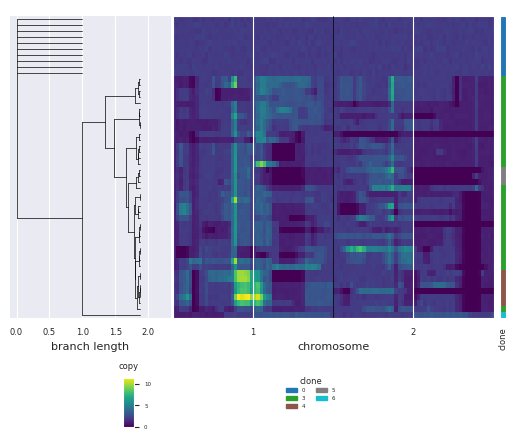

In [6]:
# plot example
adata = anndata.read_h5ad(os.path.join(data_path, "input.h5ad"))
bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', tree=bio_tree, annotation_fields=['clone'], raw=True)

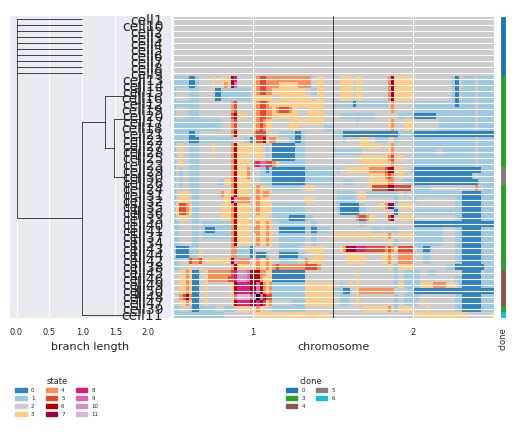

In [7]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=bio_tree, annotation_fields=['clone'], show_cell_ids=True)

# GT copy number distances

['cell11', 'cell12', 'cell13', 'cell14', 'cell15', 'cell16', 'cell17', 'cell18', 'cell19', 'cell20', 'cell21', 'cell22', 'cell23', 'cell24', 'cell25', 'cell26', 'cell27', 'cell28', 'cell29', 'cell30', 'cell31', 'cell32', 'cell33', 'cell34', 'cell35', 'cell36', 'cell37', 'cell38', 'cell39', 'cell40', 'cell41', 'cell42', 'cell43', 'cell44', 'cell45', 'cell46', 'cell47', 'cell48', 'cell49', 'cell50']


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


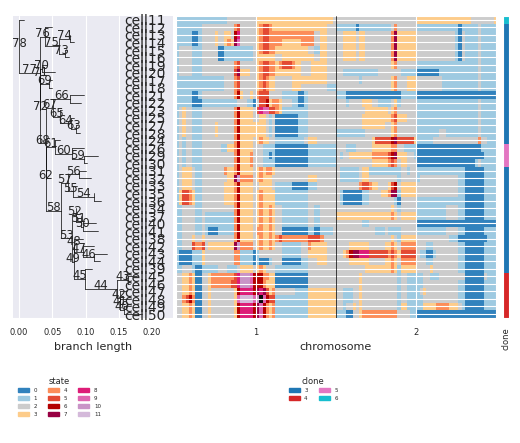

In [8]:
# use tree from cn-derived branch lengths
cell_names = adata[~adata.obs['normal']].obs_names.tolist()
print(cell_names)
dpy_tree, gt_ctr = make_gt_tree_dist(adata, n_states=7, cell_names=cell_names)
# rename dpy tree cells
for leaf in dpy_tree.leaf_node_iter():
    leaf.taxon.label = cell_names[int(leaf.taxon.label)]
bio_tree_cn_lengths = Phylo.read(StringIO(dpy_tree.as_string(schema='newick')), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=bio_tree_cn_lengths, annotation_fields=['clone'], show_cell_ids=True)

In [9]:
gt_tree_nwk = adata.uns['cell-tree-newick']
print(gt_tree_nwk)

(cell1:1.0,cell10:1.0,cell2:1.0,cell3:1.0,cell4:1.0,cell5:1.0,cell6:1.0,cell7:1.0,cell8:1.0,cell9:1.0,(((((cell13:0.01698567688120436,cell14:0.01698567688120436)ancestor7:0.01156735490011259,(cell15:0.01861368344489383,cell16:0.01861368344489383)ancestor8:0.00993934833642312)ancestor4:0.04985854301231539,cell12:0.07841157479363234)ancestor2:0.451969907631516,(((cell19:0.0062573761025448,cell20:0.0062573761025448)ancestor10:0.00106069172124682,(cell17:0.00314896280997377,cell18:0.00314896280997377)ancestor9:0.00416910501381785)ancestor5:0.39048952473042536,(((cell21:0.00505219416551859,cell22:0.00505219416551859)ancestor13:0.06026010270833844,(((cell27:0.00617347324037906,cell28:0.00617347324037906)ancestor21:0.01701979324466793,cell25:0.02319326648504699)ancestor17:0.00122457729241363,cell23:0.02441784377746061)ancestor14:0.04089445309639642)ancestor11:0.13939492886751864,((((cell29:0.00908387900190482,cell30:0.00908387900190482)ancestor22:0.01527141491713022,cell26:0.02435529391903504

In [10]:
print(bio_tree)

Tree(rooted=False, weight=1.0)
    Clade(name='root')
        Clade(branch_length=1.0, name='cell1')
        Clade(branch_length=1.0, name='cell10')
        Clade(branch_length=1.0, name='cell2')
        Clade(branch_length=1.0, name='cell3')
        Clade(branch_length=1.0, name='cell4')
        Clade(branch_length=1.0, name='cell5')
        Clade(branch_length=1.0, name='cell6')
        Clade(branch_length=1.0, name='cell7')
        Clade(branch_length=1.0, name='cell8')
        Clade(branch_length=1.0, name='cell9')
        Clade(branch_length=1.0, name='founder')
            Clade(branch_length=0.3417281897374823, name='ancestor1')
                Clade(branch_length=0.451969907631516, name='ancestor2')
                    Clade(branch_length=0.04985854301231539, name='ancestor4')
                        Clade(branch_length=0.01156735490011259, name='ancestor7')
                            Clade(branch_length=0.01698567688120436, name='cell13')
                            Clade(bra

In [11]:
em_nwk = open(os.path.join(data_path, "cm_out", "tree.nwk")).read()
print(em_nwk)

(((((((cell48:0.01136209461143671,cell49:0.021148111253650403)ancestor19:0.0015650614183483486,cell47:0.009959494027397216)ancestor12:0.006434694034351915,cell46:0.012987542384089513)ancestor7:0.000999121328674954,cell45:0.013965753589110598)ancestor4:0.007588392728413704,cell50:0.022409828409341172)ancestor2:0.01572411853475434,((((((cell29:0.019884917824410018,cell30:0.008258232387462566)ancestor25:0.008021472078117098,((cell23:0.018841648678531206,cell24:0.024658041898150795)ancestor30:0.0037907029072287227,((cell27:0.0038528017351487404,cell28:0.006600906059447668)ancestor36:0.0017175130240497313,cell25:0.005478137390296704)ancestor31:0.004879647227862816)ancestor26:0.001462675012405712)ancestor20:0.003619220913224891,cell26:0.0196909342379865)ancestor13:0.00764867566200908,(cell21:0.017418482472588984,cell22:0.02415748508394611)ancestor14:0.008258340908097045)ancestor8:0.0018840271190964375,(((((cell43:0.01930197576432568,cell44:0.014832901026463731)ancestor32:0.006761143807071053

In [12]:
inferred_tree = Phylo.read(os.path.join(data_path, "cm_out", "tree.nwk"), 'newick')

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


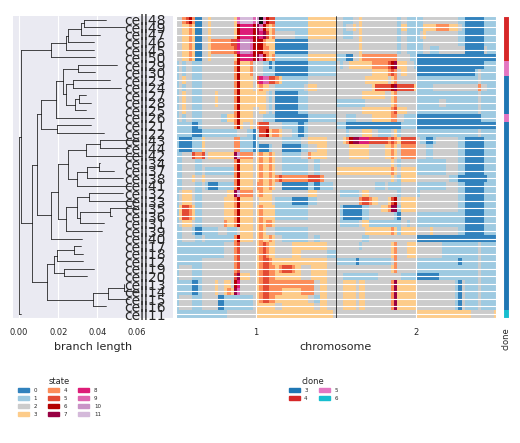

In [13]:
# output tree
# print(inferred_tree)
g = pl.plot_cell_cn_matrix_fig(adata[~adata.obs['normal']], layer_name='state', tree=inferred_tree, annotation_fields=['clone'], show_cell_ids=True)


In [14]:
print(inferred_tree)

Tree(rooted=False, weight=1.0)
    Clade(name='root')
        Clade(branch_length=0.0007657641225034769, name='ancestor1')
            Clade(branch_length=0.01572411853475434, name='ancestor2')
                Clade(branch_length=0.007588392728413704, name='ancestor4')
                    Clade(branch_length=0.000999121328674954, name='ancestor7')
                        Clade(branch_length=0.006434694034351915, name='ancestor12')
                            Clade(branch_length=0.0015650614183483486, name='ancestor19')
                                Clade(branch_length=0.01136209461143671, name='cell48')
                                Clade(branch_length=0.021148111253650403, name='cell49')
                            Clade(branch_length=0.009959494027397216, name='cell47')
                        Clade(branch_length=0.012987542384089513, name='cell46')
                    Clade(branch_length=0.013965753589110598, name='cell45')
                Clade(branch_length=0.02240982840934117

In [15]:
adata.uns['cnasim-params']


{'Time': 10,
 'WGD': False,
 'bin_length': 1000000,
 'chrom_arm_rate': 0.75,
 'chrom_arm_ratio': 0.5,
 'chrom_event_type': 0.5,
 'chrom_length': 50000000,
 'chrom_level_event': False,
 'chrom_rate_clone': 1,
 'chrom_rate_founder': 2,
 'chrom_rate_super_clone': 1,
 'clone_criteria': 0,
 'cn_copy_param': 0.8,
 'cn_event_rate': 0.5,
 'cn_length_mean': 10000000,
 'coverage': 0.1,
 'disable_info': False,
 'error_rate_1': 0.04,
 'error_rate_2': 0.1,
 'founder_event_mult': 10,
 'growth_rate': 0.003785,
 'interval': 3,
 'lorenz_x': 0.5,
 'lorenz_y': 0.4,
 'min_cn_length': 1000,
 'mode': 1,
 'normal_fraction': 0.2,
 'num_cells': 50,
 'num_chromosomes': 2,
 'num_clones': 2,
 'num_sweep': 0,
 'out_path': ' results/data/R2_N50_M100_K2_L2_E10.04_E20.1_C2/cnasim_tmp',
 'placement_param': 2,
 'placement_type': 0,
 'processors': 1,
 'pseudonormal_fraction': 0,
 'read_length': 150,
 'region_length': 1000,
 'selection_strength': 0.01,
 'seq_error': 0.02,
 'tree_type': 0,
 'use_hg38_static': False,
 'use

# CNAsim benchmark data visualization
Visualize CNAsim dataset from their published benchmarks: [zenodo link](https://zenodo.org/records/10108731)

In [76]:
test_dat = "/home/vittorio.zampinetti/data/cnasim_simulated_datasets/CNAsim/D4_1/1"
tree_nwk_path = os.path.join(test_dat, "tree.nwk")
test_tree_bio = Phylo.read(tree_nwk_path,'newick')

In [79]:
from cellmates.common_helpers.cnasim_data import profiles_to_anndata
test_adata_cn = profiles_to_anndata(os.path.join(test_dat, "profiles.tsv"))
# add tree to uns
test_adata_cn.uns['tree_newick'] = open(tree_nwk_path, 'r').read()
test_adata_cn

AnnData object with n_obs × n_vars = 250 × 2879
    var: 'chr', 'start', 'end'
    uns: 'tree_newick'

In [74]:
# test_adata_cn.write_h5ad("/home/vittorio.zampinetti/data/cnasim_benchmark_A3_0_1.h5ad")

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


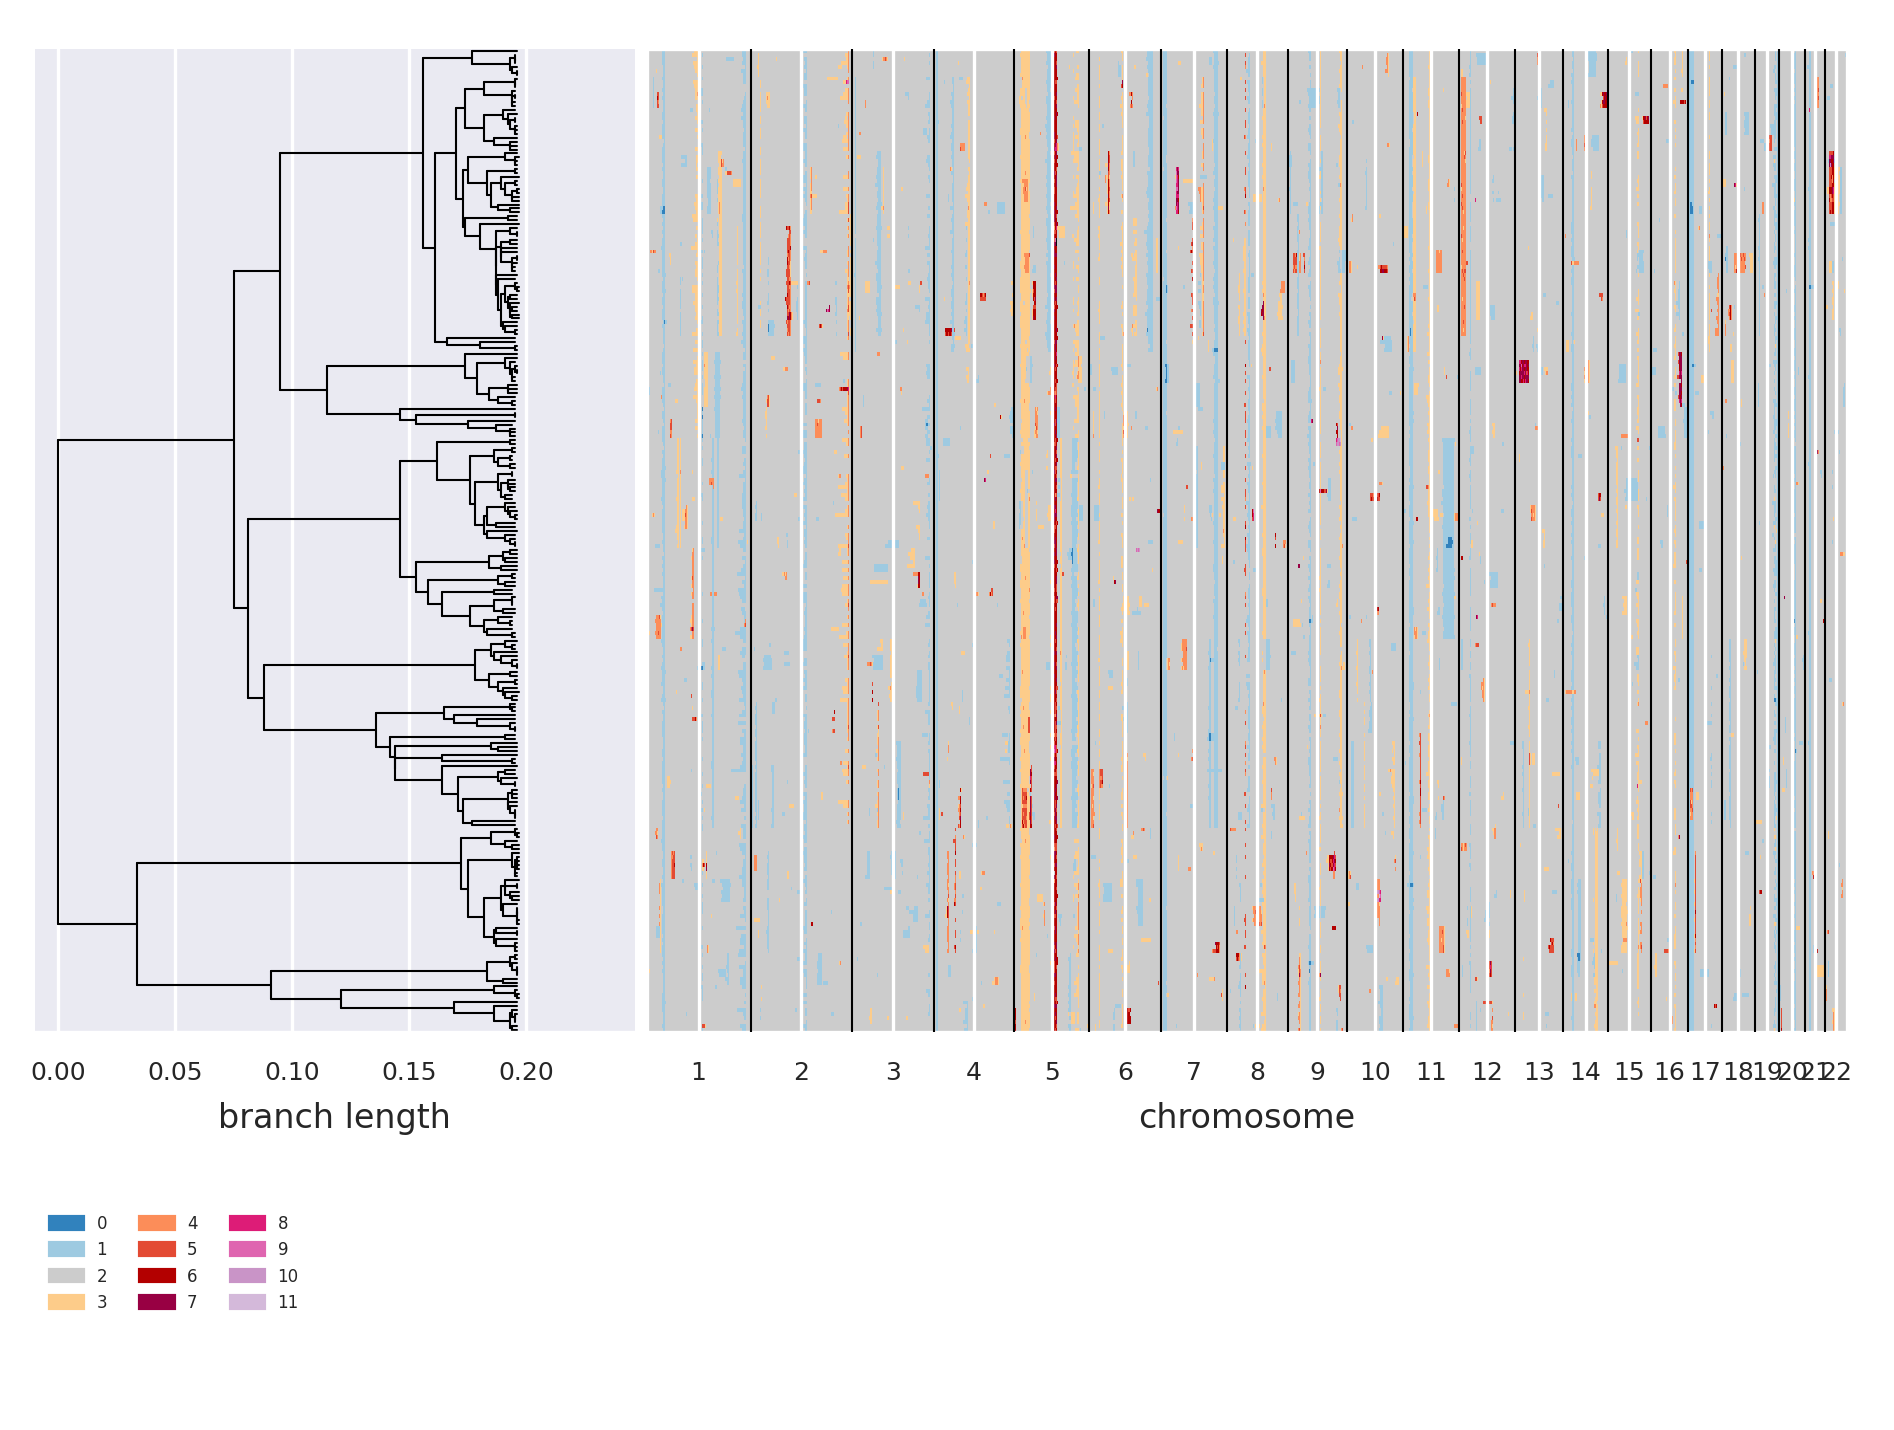

In [80]:
import matplotlib.pyplot as plt
fig = plt.figure(tight_layout=True, dpi=300)
# remove grid from fig
fig.clf()
g = pl.plot_cell_cn_matrix_fig(test_adata_cn, layer_name=None, tree=test_tree_bio, fig=fig)

In [69]:
test_adata_cn.uns['tree_newick']

'((leaf1:0.003,leaf2:0.003):0.149,((((leaf5:0.019,((leaf20:0.009,(leaf25:0.009,leaf26:0.009):0.001):0.008,(leaf21:0.013,leaf22:0.013):0.004):0.002):0.015,((leaf9:0.002,leaf10:0.002):0.025,(leaf11:0.014,leaf12:0.014):0.014):0.006):0.036,(leaf3:0.037,((leaf13:0.003,leaf14:0.003):0.032,(leaf15:0.035,(leaf23:0.022,leaf24:0.022):0.013):0.001):0.002):0.032):0.037,((leaf4:0.047,(leaf6:0.0,leaf7:0.0):0.047):0.052,((leaf8:0.038,(leaf16:0.019,leaf17:0.019):0.019):0.047,((leaf18:0.012,leaf19:0.012):0.073,(((leaf27:0.007,leaf28:0.007):0.022,(leaf29:0.016,(leaf31:0.011,(leaf35:0.005,leaf36:0.005):0.006):0.005):0.012):0.044,((leaf30:0.014,(leaf32:0.014,(leaf37:0.0,leaf38:0.0):0.014):0.001):0.039,((leaf33:0.016,(leaf39:0.002,leaf40:0.002):0.015):0.022,(leaf34:0.039,(leaf41:0.018,((leaf42:0.012,(leaf43:0.007,(leaf47:0.006,leaf48:0.006):0.001):0.004):0.004,((leaf44:0.002,(leaf49:0.001,leaf50:0.001):0.001):0.012,(leaf45:0.012,leaf46:0.012):0.002):0.001):0.002):0.021):0.0):0.014):0.019):0.013):0.0):0.014